# Sprache, Emotion und Kognition

Das hier ist der Code mit dem ich unsere Stimuliliste zusammengestellt habe. Ich habe ihn (hoffentlich) weitestgehend so kommentiert bzw. dokumentiert, dass man auch ohne Programmierkenntnisse verstehen sollte, was genau ich hier mache.

Wenn irgendetwas unklar ist, dann schreibt mir bitte!

## Stimuli

Wir wollen 80 Wörter und 80 Nicht-Wörter, die den untenstehenden Charakteristika entsprechen sollen. Dafür lesen wir im Folgenden einige Datensätze aus und nutzen ihre Informationen dafür, Stück für Stück unsere Stimuliliste zusammenzubauen.

### Charakteristika - Wörter
- Sprache: Englisch
- Wortart: Nomen
- Länge*: Tendenz längere Wörter (min. 4/5 Buchstaben)
- Frequenz*: möglichst breite Frequenzspanne, möglichst gut verteilt (Ceiling Effect)
- Valenz*: nur neutrale Wörter
- Kognatenstatus: Nicht-Kognaten

### Charakteristika - Nichtwörter
- möglichst gleiche Länge wie die Wörter
- Wort könnte morphologisch ein Nomen des Englischen sein

> *Diese Charakteristika werden erst etwas weiter unten fest "eingestellt".

### Vorbereitungen

Hier importieren wir einige Module und stellen unsere kontinuierlichen Charakteristika Frequenz, Länge und Valenz ein.

In [3]:
# !pip install nltk
# !pip install xlrd
# !pip install matplotlib

In [4]:
# Imports
import json
import numpy as np
import pandas as pd
import nltk
from nltk import pos_tag
from nltk.corpus import wordnet as wn
import matplotlib.pyplot as plt

In [5]:
# Hier können wir einstellen wie lang, frequent oder valent unsere Wörter sein sollen

# Frequenz: die Range geht von 0.48 bis 6.33 (Logarithmus)
MIN_FREQ = 1        # nichts zu niedrig frequentes (Zipf?)
MAX_FREQ = 4       # nichts zu hochfrequentes

# Länge: die Range geht von 1.00 bis 28.00
MIN_LENGTH = 5
MAX_LENGTH = 8

# Valenz: die Range geht von 1.26 bis 8.53
# wobei laut der Originalstudie 1 = happy und 9 = unhappy
# Idee: Davon ist die Mitte genau 4.5. Neutral sollte am Besten recht eng gefasst sein: also 4 bis 5
MIN_VALENCE = 4
MAX_VALENCE = 5

## Wörter

### Datensätze der Wörter

Wir werden im Folgenden einige Datensätze einlesen. Hier ist ein Überblick:
- Frequenz (SUBTLEX-US log10; [Brysbaert & New, 2009](https://www.ugent.be/pp/experimentele-psychologie/en/research/documents))
- Valenz ([Warriner et al., 2013](https://doi.org/10.3758/s13428-012-0314-x))
- Kognaten (CogNet; [Batsuren et al., 2019](https://www.researchgate.net/publication/335389593_CogNet_a_Large-Scale_Cognate_Database), also on [Github](https://github.com/kbatsuren/CogNet))

> $\to$ vollständige Quellen siehe unten

Für Wortarten benutzen wir zwei Methoden:
- da ein Großteil der Wörter nicht Nomen sein werden, filtern wir diese erst einmal grob heraus mit der ``pos_tag`` Methode von NLTK (Natural Language Toolkit). Die ist nicht ganz so akkurat, reicht aber zum groben Filtern, um den Datensatz zu verkleinern (und uns damit etwas Arbeit zu ersparen)
- später benutzen wir dann eine weit robustere Methode, den ''wordnet'' Korpus. Das ist aber ein bisschen aufwändiger, deswegen machen wir das erst ganz am Ende, wenn nur noch wenige Wörter übrig sind (je mehr Wörter wir überprüfen müssen, desto aufwändiger würde eine eh schon aufwändige Methode)

#### Idee
Wir fangen groß an (ein kompletter Datensatz) und sortieren nach und nach Wörter aus, die nicht zu unseren Charakteristika passen. Man kann es sich so vorstellen, dass wir jedes einzelne Wort dafür genau anschauen müssen, um zu überprüfen ob es passt oder nicht. Deswegen machen wir unser Aussortieren auch in einer bestimmten Reihenfolge, da manche Sachen leichter zu überprüfen sind (d.h., die können wir auch mal schnell bei ein paar tausend Wörtern anschauen) und manche Sachen schwerer (d.h., das machen wir lieber nur bei ein paar hunderten, weil es sonst zu lange dauert).

Und generell gilt natürlich: Methoden die schnell viele Wörter aussortieren (wie beispielsweise Wortarten) sollten wir so früh wie möglich anwenden, damit wir Wörter, die eh nicht passen, nicht unnötig ewig mit "rumschleppen".

#### Frequenz

Wir beginnen mit dem SUBTLEX Korpus. Den lesen wir ein und übernehmen ihn erst einmal komplett. Irgendwo müssen unsere Wörter ja herkommen.

In [6]:
# einlesen
df = pd.read_excel("SUBTLEXusfrequencyabove1.xls")

# Wie lang ist der Datensatz?
original_size = len(df)

# Feedback: 
print(f"Read SUBTLex dataset, found {original_size} words.")

Read SUBTLex dataset, found 60384 words.


In [7]:
# So sieht dieser Datensatz zum Beispiel aus:

# 	Word	FREQcount	CDcount	FREQlow	Cdlow	SUBTLWF	Lg10WF	SUBTLCD	Lg10CD
# 0	the	1501908	8388	1339811	8388	29449.176471	6.176644	100.000000	3.923710
# 1	to	1156570	8383	1138435	8380	22677.843137	6.063172	99.940391	3.923451
# 2	a	1041179	8382	976941	8380	20415.274510	6.017526	99.928469	3.923399
# 3	you	2134713	8381	1595028	8376	41857.117647	6.329340	99.916547	3.923348
# 4	and	682780	8379	515365	8374	13387.843137	5.834281	99.892704	3.923244

In [8]:
# jetzt können wir den Datensatz im Hinblick auf Frequenz vorverarbeiten

# Damit wir nicht aus Versehen was kaputt machen: nimm dir nur die zwei Spalten die wir wirklich brauchen und speichere sie in einem neuen Datensatz
# "Word" -> Wörter
# "Lg10WF" -> Log10 Häufigkeit (warum Log10? ist meistens bisschen stabiler mit logarithmierten Zahlen zu rechnen als mit normalen gezählten Häufigkeiten)
freq_df = df[["Word", "Lg10WF"]]

# Wir werden ab jetzt mit diesem Datensatz weiterarbeiten, deswegen benennen wir die Spalten erstmal um in etwas was wir uns besser merken können
freq_df = freq_df.rename(columns={"Word": "word"})
freq_df = freq_df.rename(columns={"Lg10WF": "freq"})

# Jetzt kann es sein, dass ein und dasselbe Wort in verschiedenen Schreibweisen in dem Datensatz auftaucht, z.B. "Mouse" und "mouse"
# Wenn wir die Wörter später im Experiment benutzen, werden die aber ja komplett großgeschrieben dargestellt
# Das heißt, wir normalisieren jetzt einmal alle Wörter
# (= alle werden jetzt gleich geschrieben - allerdings klein, weil wir später noch einen Wortarten Tagger über die Wörter laufen lassen und der mag 
# kleingeschriebene Wörter ein bisschen lieber als großgeschriebene):
freq_df["word"] = freq_df["word"].str.lower()

# Und dann nehmen wir von den Einzelhäufigkeiten der verschiedenen Schreibweisen die höchste (das Maximum)
# Bsp.: "Mouse": 1.5; "mouse": 3.3 wird zu "mouse": 3.3
# wir nehmen hier an, dass das eine gute Annäherung ist, vor allem aber:
# das ist - zumindest für unseren Zweck - auch das fairste & einfachste, da wir mit einem Logarithmus arbeiten
# Addieren der Einzelhäufigkeiten wäre daher zum Beipiel keine gute Lösung: log(a) + log(b) = log(a * b)
freq_df = freq_df.groupby("word", as_index=False).agg({"freq": max})

# Feedback:
print(f"""Preprocessed frequency, now we have {len(freq_df)} words.
      This means that we have already decluttered {original_size - len(freq_df)} words""")

# So sieht das dann aus
freq_df

Preprocessed frequency, now we have 60382 words.
      This means that we have already decluttered 2 words


,word,freq
0,a,6.017526
1,aa,1.944483
2,aaa,1.414973
3,aah,3.429591
4,aahing,0.477121
...,...,...
60377,zwieback,0.477121
60378,zydeco,1.176091
60379,zygoma,0.477121
60380,zygomatic,0.778151


In [9]:
# Jetzt können wir den Datensatz anhand unserer oben spezifizierten Frequenzkriterien kürzen
# Alles was außerhalb der Range liegt, brauchen wir nicht

# Nimm dir nur die Zeilen die größer-gleich unserer Mindesthäufigkeit und kleiner-gleich unserer Maximalhäufigkeit liegen
freq_range_df = freq_df[(freq_df["freq"] >= MIN_FREQ) & (freq_df["freq"] <= MAX_FREQ)]

# Feedback
print (f"""Found {len(freq_range_df)} words in our desired range from {MIN_FREQ} to {MAX_FREQ}.
       The highest observed frequency is {freq_range_df["freq"].max():.2f} and the lowest is {freq_range_df["freq"].min():.2f}.
       Mean: {freq_range_df["freq"].mean():.2f}, Standard deviation: {freq_range_df["freq"].std():.2f}.
       We have already decluttered {original_size - len(freq_range_df)} words""")

# So sieht das dann aus
freq_range_df

Found 37176 words in our desired range from 1 to 4.
       The highest observed frequency is 4.00 and the lowest is 1.00.
       Mean: 1.79, Standard deviation: 0.64.
       We have already decluttered 23208 words


,word,freq
1,aa,1.944483
2,aaa,1.414973
3,aah,3.429591
6,aardvark,1.342423
7,aargh,1.531479
...,...,...
60370,zs,1.041393
60371,zucchini,1.698970
60373,zulu,1.707570
60376,zurich,2.096910


#### Wortart

Über die Wortart werden wir wahrscheinlich die meisten unserer oben gesammelten Wörter wieder aussortieren. Deswegen ist es gut, wenn wir das direkt hier einmal grob machen, weil unser Datensatz dann direkt ein bisschen kleiner ist und wir weniger verarbeiten müssen (= wir brauchen weniger Ressourcen).

Dafür benutzen wir die Methode ``pos_tag``, das ist ein Wortarten-Tagset von der sogenannten Penn Treebank:

Hier gibt es verschiedene Abstufungen von Nomen, wir interessieren uns aber nur für Nomen im Singular, nicht im Plural und auch nicht für Eigennamen \
$\to$ siehe "NN" in der folgenden Übersicht

In [10]:
# nltk.help.upenn_tagset()

# NN: noun, common, singular or mass
#     common-carrier cabbage knuckle-duster Casino afghan shed thermostat
#     investment slide humour falloff slick wind hyena override subhumanity
#     machinist ...
# NNP: noun, proper, singular
#     Motown Venneboerger Czestochwa Ranzer Conchita Trumplane Christos
#     Oceanside Escobar Kreisler Sawyer Cougar Yvette Ervin ODI Darryl CTCA
#     Shannon A.K.C. Meltex Liverpool ...
# NNPS: noun, proper, plural
#     Americans Americas Amharas Amityvilles Amusements Anarcho-Syndicalists
#     Andalusians Andes Andruses Angels Animals Anthony Antilles Antiques
#     Apache Apaches Apocrypha ...
# NNS: noun, common, plural
#     undergraduates scotches bric-a-brac products bodyguards facets coasts
#     divestitures storehouses designs clubs fragrances averages
#     subjectivists apprehensions muses factory-jobs ...

In [11]:
# wir kopieren den Datensatz um nicht aus Versehen was kaputt zu machen
tag_df = freq_range_df.copy()

# dann sammeln wir alle Wörter aus unserem Datensatz in einer Liste
words = tag_df["word"].tolist()

# lassen den Tagger über die Liste laufen
tagged_words = pos_tag(words)

# und hängen die Tags an unseren Datensatz an
tag_df["pos"] = [tag for _, tag in tagged_words]

# So sieht das dann aus
tag_df

,word,freq,pos
1,aa,1.944483,NN
2,aaa,1.414973,NN
3,aah,3.429591,NN
6,aardvark,1.342423,NN
7,aargh,1.531479,NN
...,...,...,...
60370,zs,1.041393,NN
60371,zucchini,1.698970,NNP
60373,zulu,1.707570,NNP
60376,zurich,2.096910,NNP


In [12]:
# Jetzt können wir den Datensatz wieder kürzen
# Alles was kein Nomen ist, brauchen wir nicht

# Nimm dir nur die Zeilen mit der Wortart NN (Nomen)
noun_tag_df = tag_df[tag_df["pos"] == "NN"]

# Feedback
print (f"""Found {len(noun_tag_df)} words after filtering for nouns.
       We have already decluttered {original_size - len(noun_tag_df)} words""")

# So sieht das dann aus
noun_tag_df

Found 11792 words after filtering for nouns.
       We have already decluttered 48592 words


,word,freq,pos
1,aa,1.944483,NN
2,aaa,1.414973,NN
3,aah,3.429591,NN
6,aardvark,1.342423,NN
7,aargh,1.531479,NN
...,...,...,...
60365,zoos,1.602060,NN
60367,zorro,2.136721,NN
60369,zowie,1.278754,NN
60370,zs,1.041393,NN


#### Länge

Jetzt machen wir im Grunde das Gleiche, was wir mit der Frequenz und den Wortarten vorher gemacht haben, nun auch mit der Wortlänge. Für jedes Wort zählen wir die Buchstaben und hängen sie an den Datensatz ran.

In [13]:
# Kopieren um nichts kaputt zu machen
len_df = noun_tag_df.copy()

# Länge anhängen
len_df["length"] = len_df["word"].str.len()

# So sieht das dann aus
len_df

,word,freq,pos,length
1,aa,1.944483,NN,2
2,aaa,1.414973,NN,3
3,aah,3.429591,NN,3
6,aardvark,1.342423,NN,8
7,aargh,1.531479,NN,5
...,...,...,...,...
60365,zoos,1.602060,NN,4
60367,zorro,2.136721,NN,5
60369,zowie,1.278754,NN,5
60370,zs,1.041393,NN,2


In [14]:
# Kürzen anhand unserer Range von oben
len_range_df = len_df[(len_df["length"] >= MIN_LENGTH) & (len_df["length"] <= MAX_LENGTH)]

# Feedback
print (f"""Found {len(len_range_df)} words in our desired range from {MIN_LENGTH} to {MAX_LENGTH}.
       The highest observed length is {len_range_df["length"].max():.2f} and the lowest is {len_range_df["length"].min():.2f}.
       Mean: {len_range_df["length"].mean():.2f}, Standard deviation: {len_range_df["length"].std():.2f}.
       We have already decluttered {original_size - len(len_range_df)} words""")

# So sieht das dann aus
len_range_df

Found 6813 words in our desired range from 5 to 8.
       The highest observed length is 8.00 and the lowest is 5.00.
       Mean: 6.48, Standard deviation: 1.07.
       We have already decluttered 53571 words


,word,freq,pos,length
6,aardvark,1.342423,NN,8
7,aargh,1.531479,NN,5
8,aaron,2.873902,NN,5
12,aback,1.204120,NN,5
13,abacus,1.113943,NN,6
...,...,...,...,...
60334,zirconia,1.113943,NN,8
60359,zoology,1.255273,NN,7
60367,zorro,2.136721,NN,5
60369,zowie,1.278754,NN,5


#### Valenz

Ähnlich gehen wir auch bei der Valenz vor. Da wir aber noch keine Werte für Valenz haben, müssen wir zunächst erst einen weiteren Datensatz einlesen, in welchem entsprechende Werte gespeichert sind.

In [15]:
# Valenzdatensatz einlesen
valence_df = pd.read_csv("BRM-emot-submit.csv")

# Wir nehmen nur die Spalten die uns interessieren
# "Word": Wort
# "V.Mean.Sum": Durchschnittsvalenz (von Valenzratings aus einer experimentellen Studie)
valence_df = valence_df[["Word", "V.Mean.Sum"]]

# Und wieder umbenennen in etwas was wir uns besser merken können
valence_df = valence_df.rename(columns={"Word": "word"})
valence_df = valence_df.rename(columns={"V.Mean.Sum": "valence"})

# Feedback
print (f"""Found {len(valence_df)} words in the valence dataset.
       The highest possible valence is {valence_df["valence"].max():.2f} and the lowest is {valence_df["valence"].min():.2f}.""")

# So sieht das dann aus
valence_df

Found 13915 words in the valence dataset.
       The highest possible valence is 8.53 and the lowest is 1.26.


,word,valence
0,aardvark,6.26
1,abalone,5.30
2,abandon,2.84
3,abandonment,2.63
4,abbey,5.85
...,...,...
13910,zone,4.75
13911,zoning,4.65
13912,zoo,7.00
13913,zoom,5.86


In [16]:
# Auch hier dürfen wir wieder normalisieren, d.h. alles kleinschreiben
# (schließlich müssen wir die Wörter aus diesem Datensatz gleich mit unseren Wörtern von oben abgleichen und die sind ja auch normalisiert)
valence_df["word"] = valence_df["word"].str.lower()

# Und falls wir ein und dasselbe Wort in verschiedenen Schreibweisen haben (siehe Mouse - mouse Beispiel von oben),
# nehmen wir in solchen Fällen die Durchschnittsvalenz aller Schreibweisen
mean_valence_df = valence_df.groupby("word", as_index=False)["valence"].mean()

# Feedback
print (f"""Found {len(mean_valence_df)} words in the valence dataset after normalizing words.
       The highest possible valence is {mean_valence_df["valence"].max():.2f} and the lowest is {mean_valence_df["valence"].min():.2f}.
       This means that {len(valence_df) - len(mean_valence_df)} words were collapsed.""")

# So sieht das dann aus
mean_valence_df

Found 13904 words in the valence dataset after normalizing words.
       The highest possible valence is 8.53 and the lowest is 1.26.
       This means that 11 words were collapsed.


,word,valence
0,aardvark,6.26
1,abalone,5.30
2,abandon,2.84
3,abandonment,2.63
4,abbey,5.85
...,...,...
13899,zone,4.75
13900,zoning,4.65
13901,zoo,7.00
13902,zoom,5.86


In [17]:
# Gleich können wir den Datensatz wieder anhand unserer spezifizierten Range kürzen
# Dafür müssen wir allerdings zuerst den soeben eingelesen Datensatz auf unseren Datensatz von oben abbilden

# Kopiere den Datensatz von oben
val_df = len_range_df.copy()

# Bilde den neuen Valenzdatensatz auf unseren Datensatz ab
# Wir hängen praktisch einfach eine neue Spalte mit Valenzen an
# Wenn ein Wort in unserem Datensatz vorhanden ist, aber nicht in dem Valenzdatensatz, dann wird die Valenz als "NaN" gezählt
val_df = val_df.merge(mean_valence_df, on= "word", how = "left")

print("Done")

# So sieht das dann aus
val_df

Done


,word,freq,pos,length,valence
0,aardvark,1.342423,NN,8,6.26
1,aargh,1.531479,NN,5,NaN
2,aaron,2.873902,NN,5,NaN
3,aback,1.204120,NN,5,NaN
4,abacus,1.113943,NN,6,NaN
...,...,...,...,...,...
6808,zirconia,1.113943,NN,8,NaN
6809,zoology,1.255273,NN,7,NaN
6810,zorro,2.136721,NN,5,NaN
6811,zowie,1.278754,NN,5,NaN


In [18]:
# Jetzt kürzen wir
# Alles was außerhald der oben spezifizierten Range ist fliegt raus
# Sowie auch alle Wörter bei denen die Valenz unbekannt ist (NaNs)
val_range_df = val_df[(val_df["valence"] >= MIN_VALENCE) & (val_df["valence"] <= MAX_VALENCE) & (val_df["valence"].notna())]

# Feedback
print (f"""Found {len(val_range_df)} words in our desired range: {MIN_VALENCE} - {MAX_VALENCE}.
       The highest valence is {val_range_df["valence"].max():.2f} and the lowest is {val_range_df["valence"].min():.2f}.
       Mean: {val_range_df["valence"].mean():.2f}, Standard deviation: {val_range_df["valence"].std():.2f}.
       We have already decluttered {original_size - len(val_range_df)} words""")

# So sieht das dann aus
val_range_df

Found 941 words in our desired range: 4 - 5.
       The highest valence is 5.00 and the lowest is 4.00.
       Mean: 4.57, Standard deviation: 0.29.
       We have already decluttered 59443 words


,word,freq,pos,length,valence
19,abreast,1.431364,NN,7,4.62
23,absolve,1.477121,NN,7,4.58
24,abstain,1.431364,NN,7,4.40
49,adder,1.869232,NN,5,4.45
57,adjuster,1.322219,NN,8,4.25
...,...,...,...,...,...
6765,wrecker,1.431364,NN,7,4.05
6766,wrestle,2.247973,NN,7,4.53
6767,wrestler,1.963788,NN,8,4.26
6771,wrinkle,1.986772,NN,7,4.00


#### Nomen #2

Der erste Wortartenfilter mit ``pos_tag`` war nur eine grobe Vorauswahl. Nun überprüfen wir die verbleibenden Wörter mit ``WordNet``, einer deutlich umfangreicheren linguistischen Datenbank. Dadurch können wir zuverlässiger einschätzen, ob ein Wort tatsächlich auch hauptsächlich als Nomen verwendet wird.

WordNet speichert für viele Wörter verschiedene Bedeutungen ("Synsets"). Manche Wörter kommen als Nomen, Verben oder Adjektive vor. Wir zählen daher, wie häufig ein Wort als Nomen im Vergleich zu anderen Wortarten vertreten ist. Daraus berechnen wir einen Wert zwischen 0 und 1:

- 1 = praktisch ausschließlich Nomen
- 0 = praktisch nie Nomen

In [19]:
# Funktion, mit der wir die verschiedenen Bedeutungen zählen können
# und dann jedem Wort ein "Rating" seiner "Nomenhaftigkeit" geben können
def noun_score(word):
    noun_synsets = wn.synsets(word, pos=wn.NOUN)
    verb_synsets = wn.synsets(word, pos=wn.VERB)
    adj_synsets  = wn.synsets(word, pos=wn.ADJ)

    noun_count = len(noun_synsets)
    other_count = len(verb_synsets) + len(adj_synsets)

    return noun_count / (noun_count + other_count + 1e-9)

In [20]:
# kopiere den Datensatz von oben
wn_noun_df = val_range_df.copy()

# hänge unsere Nomen-Ratings an
wn_noun_df["noun_score"] = wn_noun_df["word"].apply(noun_score)

# behalte nur diejenigen Wörter, die oft als Nomen genutzt werden
wn_noun_df = wn_noun_df[wn_noun_df["noun_score"] >= 0.7]

# Feedback
print (f"""Found {len(wn_noun_df)} words that are very likely nouns and also often used as such.
       We have already decluttered {original_size - len(wn_noun_df)} words""")

# So sieht das dann aus
wn_noun_df

Found 512 words that are very likely nouns and also often used as such.
       We have already decluttered 59872 words


,word,freq,pos,length,valence,noun_score
49,adder,1.869232,NN,5,4.45,1.0
57,adjuster,1.322219,NN,8,4.25,1.0
70,advisor,2.354108,NN,7,4.74,1.0
109,albino,1.778151,NN,6,4.90,1.0
113,alcohol,2.927370,NN,7,4.11,1.0
...,...,...,...,...,...,...
6717,winger,1.431364,NN,6,4.95,1.0
6756,wormhole,1.995635,NN,8,4.95,1.0
6765,wrecker,1.431364,NN,7,4.05,1.0
6767,wrestler,1.963788,NN,8,4.26,1.0


#### Kognaten

Im nächsten Schritt wollen wir Kognaten aussortieren. Da wir jedoch noch keine Informationen über den Kognatenstatus unserer Wörter haben, lesen wir dafür zunächst einen weiteren Datensatz ein. Mithilfe des sogenanntem CogNet-Datensatzes suchen wir nach englischen Wörtern, die als deutsche Kognaten markiert sind, und entfernen diese.

Das Durchsuchen der gesamten CogNet-Datenbank dauert mehrere Minuten, da diese wirklich sehr groß ist. Deshalb speichern wir die gefundenen Kognaten einmalig in einer Datei. Bei späteren Durchläufen können wir die Datei direkt laden und müssen die Berechnung nicht erneut durchführen.

Am Ende haben wir ein Set (~ eine große Liste) mit Englisch-Deutsch Kognaten, mit denen wir unsere Wörter abgleichen können.

In [21]:
# das ist ein sehr großer Datensatz, da hier Kognaten aller möglichen Sprachen gespeichert sind
# wir lassen das einmal laufen, speichern die gefundenen Englisch-Deutsch Kognaten in der Cache-Datei cognate_set.json
# und machen in Zukunft dann alles nur noch mit dieser Datei

# der folgende Code sucht nach eben dieser Datei:
# wenn sie vorhanden ist (im gleichen Ordner), dann öffnen wir diese und arbeiten nur mit ihr
# wenn nicht, dann verarbeiten wir den großen Datensatz aller Kognaten und stellen uns erstmal ein Englisch-Deutsch Set zusammen,
# mit dem wir dann weiterarbeiten können

cache_file = "cognate_set.json"

# versuche die Cache-Datei zu laden
try:
    with open(cache_file, "r") as f:
        cognate_set = set(json.load(f))
    # Feedback
    print(f"Loaded cognate_set with {len(cognate_set)} items\n")

# wenn das nicht geht, dann erstelle ein neues Englisch-Deutsch Kognaten Set und speichere dieses in der Cache-Datei
except FileNotFoundError:
    # Kognaten-Datensatz einlesen
    cognate_df = pd.read_csv("CogNet-v1.0.tsv", sep="\t")

    cognate_set = set()

    for _, r in cognate_df.iterrows():
        w1, l1 = r["word 1"], r["lang 1"]
        w2, l2 = r["word 2"], r["lang 2"]

        if l1 == "eng" and l2 == "deu":
            cognate_set.add(str(w1))
        elif l2 == "eng" and l1 == "deu":
            cognate_set.add(str(w2))

    with open(cache_file, "w") as f:
        json.dump(list(cognate_set), f)

    # Feedback
    print(f"Computed and saved cognate_set with {len(cognate_set)} items\n")

# So sieht das dann aus
for item in list(cognate_set)[:10]:
    print(item)

Loaded cognate_set with 7196 items

wildcat
ufo
gigantism
tomato sauce
condition
pediatrics
idol
postulate
genocide
abelmoschus moschatus


In [22]:
# kopiere den Datensatz von oben
non_cognate_df = wn_noun_df.copy()

# übernehme nur die Wörter, die nicht in dem Kognaten-Set vorhanden sind
non_cognate_df = non_cognate_df[~non_cognate_df["word"].isin(cognate_set)]

# Feedback
print (f"""Found {len(non_cognate_df)} words that are not cognates.
       We have already decluttered {original_size - len(non_cognate_df)} words""")

# So sieht das dann aus
non_cognate_df

Found 363 words that are not cognates.
       We have already decluttered 60021 words


,word,freq,pos,length,valence,noun_score
49,adder,1.869232,NN,5,4.45,1.0
57,adjuster,1.322219,NN,8,4.25,1.0
70,advisor,2.354108,NN,7,4.74,1.0
114,alderman,1.623249,NN,8,4.44,1.0
116,alfalfa,1.531479,NN,7,4.79,1.0
...,...,...,...,...,...,...
6701,wiener,2.056905,NN,6,4.74,1.0
6717,winger,1.431364,NN,6,4.95,1.0
6756,wormhole,1.995635,NN,8,4.95,1.0
6765,wrecker,1.431364,NN,7,4.05,1.0


### Zwischenstopp

Wir haben jetzt alle unsere Wortkriterien abgeklappert und haben jetzt nur noch Wörter, die:
1) sehr sehr wahrscheinlich Nomen des Englischen sind und auch meistens so verwendet werden
2) wahrscheinlich keine Kognaten sind (das werden wir aber auch manuell noch einmal überprüfen)
3) in Länge, Frequenz und Valenz unseren Vorstellungen entsprechen

#### Nächste Schritte:
$\to$ grobe manuelle Überprüfung des Nomen- und Kognaten-Status unserer Wörter \
    (*Was, wenn ein Wort ein Kognat ist, der nicht in dem Kognatendatensatz aufgetaucht ist?*) \
$\to$ Entfernen eventueller fehlerhafter Wörter \
$\to$ weiteres Ausbalancieren der Frequenz durch Simulierung einer uniformen Verteilung

### Manuelle Analyse

Wir machen jetzt eine grobe manuelle Überprüfung unserer gesammelten Stimuli. Wörter, die wider Erwarten doch Kognaten oder nicht Nomen sind, fügen wir zur Textdatei ``manual_faulty_words.txt`` hinzu. Ebenso Wörter, die aus irgendeinem anderen Grund nicht aufgenommen werden sollen.

Diese sortieren wir dann aus. Diesen Schritt können wir beliebig oft wiederholen (einfach immer mehr Wörter zur Datei hinzufügen), bis wir endlich mit allen Wörtern zufrieden sind.

In [23]:
# kopieren
corrected_df = non_cognate_df.copy()

# lese die Datei mit den zu entfernenden Wörtern ein und speichere sie in einem Set
manual_correction_set = set()
with open ("manual_faulty_words.txt", "r", encoding = "utf-8") as file:
    for line in file:
        word = line.strip()
        manual_correction_set.add(word)

# übernehme nur die Wörter, die nicht in dem Korrektur-Set vorhanden sind
corrected_df = corrected_df[~corrected_df["word"].isin(manual_correction_set)]

# Feedback
print (f"""Found {len(corrected_df)} words that fit our prerequisites.
       In total, we have decluttered {original_size - len(corrected_df)} words""")

# So sieht das dann aus
corrected_df

Found 310 words that fit our prerequisites.
       In total, we have decluttered 60074 words


,word,freq,pos,length,valence,noun_score
49,adder,1.869232,NN,5,4.45,1.0
57,adjuster,1.322219,NN,8,4.25,1.0
70,advisor,2.354108,NN,7,4.74,1.0
114,alderman,1.623249,NN,8,4.44,1.0
116,alfalfa,1.531479,NN,7,4.79,1.0
...,...,...,...,...,...,...
6694,wicker,1.690196,NN,6,4.79,1.0
6701,wiener,2.056905,NN,6,4.74,1.0
6717,winger,1.431364,NN,6,4.95,1.0
6756,wormhole,1.995635,NN,8,4.95,1.0


In [24]:
# TODO: delete
# gib mir jedes einzelne Item aus
# for _, row in corrected_df.iterrows():
#     print ("\n", row)

### Uniforme Verteilung der Frequenzen

Wir wollen Wörter, die eine möglichst breite Range an Frequenz abdecken. Momentan könnte es noch sein, dass wir zwar Wörter zwischen unserer Minimal- und Maximalfrequenz ausgewählt haben, aber zum Beispiel ein Großteil dieser Wörter sich dort eher im hochfrequenten Bereich einordnen lässt (oder im niedrigfrequenten). Am Besten wäre es jedoch, wenn wir eine Art unifmore Verteilung über unsere mögliche Frequenzspanne hinbekommen würden, sodass unsere Frequenz auch innerhalb dieser Spanne möglichst gut ausbalanciert ist.

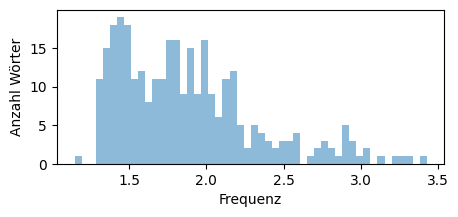

In [25]:
# So sieht unsere Verteilung momentan aus
plt.figure(figsize=(5, 2))
plt.hist(corrected_df["freq"], bins=50, alpha=0.5, label="Original")
plt.xlabel("Frequenz")
plt.ylabel("Anzahl Wörter")
plt.show()

#### Idee

Im Idealfall möchten wir Wörter auswählen, die den gesamten Frequenzbereich möglichst gleichmäßig abdecken. Aktuell ist das jedoch nicht der Fall: Die meisten verbleibenden Wörter haben eine niedrige Frequenz, während nur wenige Wörter eine hohe Frequenz besitzen.

Das bedeutet, dass bestimmte Bereiche der Frequenzskala stark überrepräsentiert sind, andere dagegen kaum vorkommen. Für unsere spätere Wortliste wäre es jedoch wünschenswert, dass niedrige, mittlere und hohe Frequenzen ungefähr gleich stark vertreten sind.

Da wir bereits viele Wörter durch unsere vorherigen Filter entfernt haben, können wir keine perfekt gleichmäßige Verteilung mehr erreichen. Wir können aber versuchen, uns ihr anzunähern.

Die Grundidee ist einfach: Wir legen auf der Frequenzskala mehrere gleichmäßig verteilte Zielpunkte fest und wählen jeweils das Wort aus, dessen Frequenz diesem Zielpunkt am nächsten liegt.

Nehmen wir als Beispiel eine Frequenzspanne von 0 bis 10. Unsere verbliebenen Wörter haben die folgenden Frequenzen:

* A: 1.5
* B: 1.6
* C: 1.7
* D: 1.9
* E: 3.4
* F: 5.6
* G: 6.9
* H: 9.9

Man erkennt, dass sich viele Wörter im unteren Bereich der Skala befinden und nur wenige im oberen Bereich.

Nun wählen wir die Zielpunkte 0, 2, 4, 6, 8 und 10. Für jeden Zielpunkt behalten wir das Wort, dessen Frequenz am nächsten liegt:

* 0 → A (1.5)
* 2 → D (1.9)
* 4 → E (3.4)
* 6 → F (5.6)
* 8 → G (6.9)
* 10 → H (9.9)

Die übrigen Wörter werden entfernt.

Auf diese Weise erhalten wir eine Wortliste, die den gesamten Frequenzbereich besser abdeckt, anstatt sich hauptsächlich auf einen kleinen Teil der Skala zu konzentrieren.

Dabei treffen wir zwei Annahmen:
1) wir finden alle Wörter gleich gut (wir haben ja oben bereits manuell alle probelmatischen Wörter aussortiert)
2) Wir haben zu viele Wörter und wollen einen systematischen Ansatz, um einige davon zu entfernen \
(d.h., wenn wir schon nur einen Teil unserer jetzigen Wörter weiter verwenden können, dann bevorzugen wir eine Auswahl, die den Frequenzbereich möglichst gleichmäßig abdeckt)

In [26]:
# kopieren
uniform_df = corrected_df.copy()

# Wie viele Wörter wollen wir am Ende haben? -> 80
# NOTE: für den Moment wählen wir 100, damit wir nochmal die Möglichkeit haben auszusortieren
N = 100

# Wir wollen 100 Zielpunkte innerhalb unserer Spanne zwischen Mindest- und Maximalfrequenz
# diese haben jeweils den gleichen Abstand zueinander
targets = np.linspace(MIN_FREQ, MAX_FREQ, N)

# Für jeden Zielpunkt: wähle das Wort, dessen Frequenz am nahesten ist
selected = []
for target in targets:
    idx = (uniform_df["freq"] - target).abs().idxmin()
    selected.append(uniform_df.loc[idx])
    uniform_df = uniform_df.drop(idx)

sampled = pd.DataFrame(selected)

# Feedback
print (f"""Found {len(sampled)} words that fit our prerequisites.
       In total, we have decluttered {original_size - len(sampled)} words.\n
       The highest observed frequency is {sampled["freq"].max():.2f} and the lowest is {sampled["freq"].min():.2f}.
       Mean: {sampled["freq"].mean():.2f}, Standard deviation: {sampled["freq"].std():.2f}.\n
       The highest observed length is {sampled["length"].max():.2f} and the lowest is {sampled["length"].min():.2f}.
       Mean: {sampled["length"].mean():.2f}, Standard deviation: {sampled["length"].std():.2f}.
       """)

# So sieht das dann aus
sampled

Found 100 words that fit our prerequisites.
       In total, we have decluttered 60284 words.

       The highest observed frequency is 3.43 and the lowest is 1.15.
       Mean: 2.22, Standard deviation: 0.58.

       The highest observed length is 8.00 and the lowest is 5.00.
       Mean: 6.55, Standard deviation: 1.10.
       


,word,freq,pos,length,valence,noun_score
2052,dustpan,1.146128,NN,7,4.67,1.00
57,adjuster,1.322219,NN,8,4.25,1.00
2247,fallacy,1.322219,NN,7,4.00,1.00
2320,finality,1.322219,NN,8,4.43,1.00
2589,girder,1.322219,NN,6,4.53,1.00
...,...,...,...,...,...,...
5774,squire,2.198657,NN,6,4.67,0.75
6128,tenant,2.193125,NN,6,4.57,0.75
3734,marrow,2.181844,NN,6,4.29,1.00
4856,receiver,2.181844,NN,8,4.90,1.00


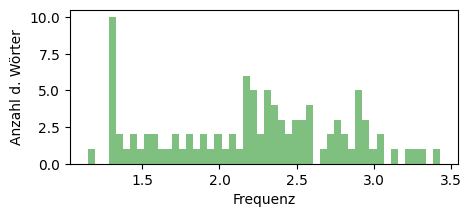

In [27]:
# So sieht unsere Verteilung jetzt aus

plt.figure(figsize=(5, 2))
plt.hist(sampled["freq"], bins=50, alpha=0.5, label="Sampled", color = "green")
plt.xlabel("Frequenz")
plt.ylabel("Anzahl d. Wörter")
plt.show()

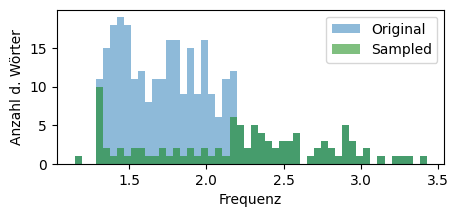

In [28]:
# Vergleich vorher-nachher
plt.figure(figsize=(5, 2))
plt.hist(corrected_df["freq"], bins=50, alpha=0.5, label="Original")
plt.hist(sampled["freq"], bins=50, alpha=0.5, label="Sampled", color = "green")
plt.xlabel("Frequenz")
plt.ylabel("Anzahl d. Wörter")
plt.legend()
plt.show()

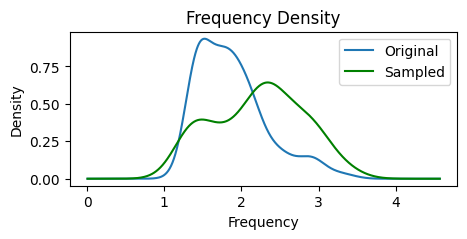

In [29]:
# !pip install scipy

import scipy
# density comparison

plt.figure(figsize=(5, 2))

corrected_df["freq"].plot(kind="density", label="Original")
sampled["freq"].plot(kind="density", label="Sampled", color = "green")

plt.xlabel("Frequency")
plt.title("Frequency Density")
plt.legend()

plt.show()

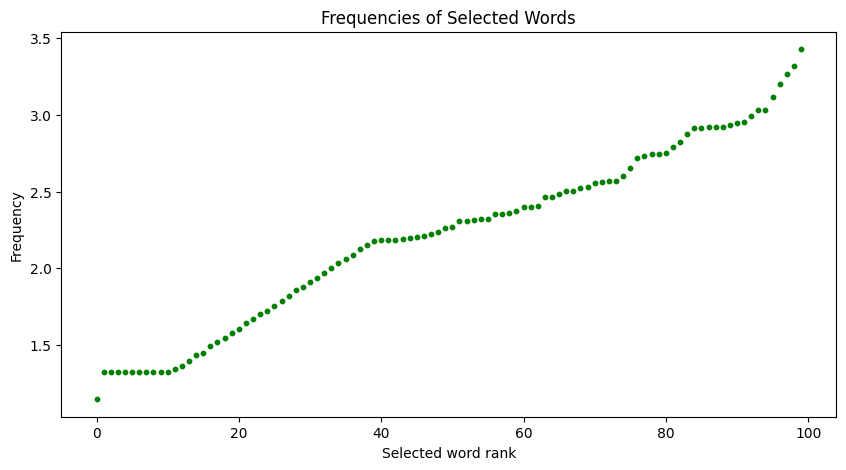

In [30]:
# check uniformity directly

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(sampled)),
    sampled["freq"].sort_values(),
    s=10,
    color = "green"
)

plt.xlabel("Selected word rank")
plt.ylabel("Frequency")
plt.title("Frequencies of Selected Words")

plt.show()

## Nicht-Wörter

Nun kommen wir zu den Nicht-wörtern. Diese sollen den Wörtern so ähnlich wie möglich sein:
- Wort könnte morphologisch ein Nomen des Englischen sein
- möglichst gleiche Länge wie die Wörter

Als Quelle für unsere Nicht-wörter benutzen wir die ARC Nonword Database ([Rastle et al., 2002](http://www.cogsci.mq.edu.au/research/resources/nwdb/nwdb.html)). Das ist eine Datenbank für englische Nonwords, die man im Browser durchsuchen kann.

Ich habe folgende Einstellungen vorgenommen:
* only orthographically existing onsets
* only orthographically existing bodies
* only legal bigrams

Dadurch können wir sicherstellen, dass die Wörter morphologisch Wörter des Englischen sein könnten.

Für Länge habe ich außerdem eingestellt:
* Länge 5 - 8 (wie bei den Wörtern oben)

$\to$ Allerdings werden wir in einem folgenden Schritt die Länge der Nicht-Wörter noch spezifischer auf die Länge der Wörter matchen.

Die resultierenden Nonwords habe ich in einer Textdatei (``nonwords_original_results.txt``) gespeichert.

Im Folgenden werden wir diese mit einer Mischung aus manuellem Aussortieren und Längen-Matching weiter kürzen.
Längen-Matching, damit die Nonwords nicht nur in ihrer groben Wortlängen-Spanne den Wörtern ähneln, sondern im besten Fall auch eine ähnliche Verteilung aufweisen. Manuelles Aussortieren, damit unsere Nonwords nicht nur Wörtern des Englischen, sondern spezifisch **Nomen** des Englischen ähneln. Außerdem stellen wir dadurch sicher, dass sich nicht aus Versehen tatsächlich existierende Wörter eingeschlichen haben.

In [31]:
nonwords = []

with open("nonwords_original_results_clean.txt", "r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()

        if not line:
            continue

        parts = line.split()

        nonword = parts[0]
        length = parts[2]

        nonwords.append((nonword, int(length)))

initial_nonwords_df = pd.DataFrame(nonwords, columns = ["nonword", "length"])

# Feedback:
original_nonword_size = len(initial_nonwords_df)
print(f"Read nonword file, found {original_nonword_size} words.")

initial_nonwords_df

Read nonword file, found 56909 words.


,nonword,length
0,paiths,6
1,neeced,6
2,shazed,6
3,grorne,6
4,glease,6
...,...,...
56904,whoms,5
56905,yermed,6
56906,ghouch,6
56907,knasks,6


### Automatisches Aussortieren

In [32]:
# kopieren
auto_correct_df = initial_nonwords_df.copy()

# erstmal mit Füller-Werten arbeiten
auto_correct_df["could_be_sg_noun"] = "NA"

# Nomen im Englischen enden selten auf "-ed", diese Nicht-Wörter können wir also aussortieren
auto_correct_df.loc[auto_correct_df["nonword"].str.endswith("ed"), "could_be_sg_noun"] = "unlikely"

# Singularnomen enden selten auf -s, diese Nicht-Wörter können wir auch aussortieren
auto_correct_df.loc[auto_correct_df["nonword"].str.endswith("s"), "could_be_sg_noun"] = "unlikely"



# Wir behalten nur diejenigen Einträge, die weiterhin NA beinhalten
auto_correct_df = auto_correct_df[auto_correct_df["could_be_sg_noun"] == "NA"]

# Feedback
print (f"""Found {len(auto_correct_df)} words that could be nouns in the English language.
       In total, we have decluttered {original_nonword_size - len(auto_correct_df)} words""")

# So sieht das dann aus
auto_correct_df

Found 22922 words that could be nouns in the English language.
       In total, we have decluttered 33987 words


,nonword,length,could_be_sg_noun
3,grorne,6,NA
4,glease,6,NA
5,timpse,6,NA
6,scife,5,NA
12,skauk,5,NA
...,...,...,...
56898,chang,5,NA
56900,younce,6,NA
56901,slerge,6,NA
56902,gwarge,6,NA


### Manuelles Aussortieren

Auch hier möchten wir nicht nur automatisch, sondern auch manuell filtern können.  Wörter, die nicht Nomen des Englischen sein könnten, fügen wir zur Textdatei ``manual_faulty_nonwords.txt`` hinzu. Ebenso Wörter, die aus irgendeinem anderen Grund nicht aufgenommen werden sollen.

Diese sortieren wir dann aus. Diesen Schritt können wir beliebig oft wiederholen (einfach immer mehr Wörter zur Datei hinzufügen), bis wir endlich mit allen Wörtern zufrieden sind.

> $\to$ Aufgrund der schieren Menge an möglichen Nicht-Wörtern ist das ein iterativer Prozess: Zuerst ist die Datei leer und wir sortieren keine Wörter aus. Dann matchen wir 100 Nicht-Wörter auf die Länge der Wörter und schauen uns diese genauer an. Sind da welche dabei die wir probelmatisch finden, fügen wir diese zur Datei hinzu und sortieren sie dann aus. Dann matchen wir die verbleibenden Wörter wieder auf Länge und schauen sie uns an $-$ solange bis wir mit allen Nicht-Wörtern zufrieden sind (im besten Falle passiert das, ohne dass wir uns komplett alle möglichen Nicht-Wörter anschauen müssen).

In [33]:
# kopieren
corrected_nw_df = auto_correct_df.copy()

# lese die Datei mit den zu entfernenden Wörtern ein und speichere sie in einem Set
manual_correction_set = set()
with open ("manual_faulty_nonwords.txt", "r", encoding = "utf-8") as file:
    for line in file:
        nonword = line.strip()
        manual_correction_set.add(nonword)

# übernehme nur die Wörter, die nicht in dem Korrektur-Set vorhanden sind
corrected_nw_df = corrected_nw_df[~corrected_nw_df["nonword"].isin(manual_correction_set)]

# Feedback
print (f"""Found {len(corrected_nw_df)} words that fit our prerequisites.
       In total, we have decluttered {original_nonword_size - len(corrected_nw_df)} words""")

# So sieht das dann aus
corrected_nw_df

Found 22921 words that fit our prerequisites.
       In total, we have decluttered 33988 words


,nonword,length,could_be_sg_noun
3,grorne,6,NA
4,glease,6,NA
5,timpse,6,NA
6,scife,5,NA
12,skauk,5,NA
...,...,...,...
56898,chang,5,NA
56900,younce,6,NA
56901,slerge,6,NA
56902,gwarge,6,NA


### Länge

Um die Nicht-Wörter in Bezug auf Länge ganz genau an die WÖrter anzupassen, zählen wir nun zunächst, wie viele Wörter in unserem Wörter-Datensatz welche Wortlänge haben. Das zeigt uns, wie viele Nicht-Wörter wir für die jeweiligen Wortlängen benötigen. Dann ziehen wir uns zufällig genau so viele heraus.

Anmerkung: wir fixieren aber die Zufälligkeit, das heißt, auch wenn wir das hier mehrmals durchführen, sollten immer die gleichen Wörter herauskommen (wichtig) $-$ es sei denn natürlich wir verändern etwas an den äußeren Umständen (wie zum Beispiel der Wortliste).

In [34]:
# Wie viele Wörter haben welche Wortlänge?
matched_nonwords = (sampled["length"].value_counts().sort_index())
matched_nonwords

length
5    22
6    27
7    25
8    26
Name: count, dtype: int64

In [35]:
# ziehe dir die benötigten Nicht-Wörter heraus

selected_nonwords = []

for length, n_needed in matched_nonwords.items():

    # alle Kandidaten die eine bestimmte Wortlänge haben
    candidates = corrected_nw_df[corrected_nw_df["length"] == length]

    if len(candidates) < n_needed:
        raise ValueError(
            f"Need {n_needed} nonwords of length {length}, "
            f"but only {len(candidates)} available."
        )

    selected_nonwords.append(candidates.sample(n=n_needed, random_state=42))

selected_nonwords = pd.concat(selected_nonwords).reset_index(drop=True)

# Feedback:
print(f"""Matched Nonwords on length, now we have {len(selected_nonwords)} words.
      This means that we have already decluttered {original_nonword_size - len(selected_nonwords)} words""")

# So sieht das dann aus
selected_nonwords

Matched Nonwords on length, now we have 100 words.
      This means that we have already decluttered 56809 words


,nonword,length,could_be_sg_noun
0,stran,5,NA
1,drime,5,NA
2,blaff,5,NA
3,grolt,5,NA
4,crint,5,NA
...,...,...,...
95,throothe,8,NA
96,splorgue,8,NA
97,treighth,8,NA
98,phrarmth,8,NA


In [36]:
# TODO: delete
# gib mir jedes einzelne Item aus
# for _, row in selected_nonwords.iterrows():
#     print ("\n", row)

## Zusammenfügen und Speichern

Wir wollen die beiden jetzt zusammenfügen. Dafür müssen wir sie zuerst soweit vorverarbeiten, dass sie die gleichen Spaltennamen haben. Das heißt wir sammeln alle möglichen Infos unter den vorgegebenen Spaltennamen und dann können wir sie einfach aneinander "ankleben". Einige Charakteristika wie Wortfrequenz oder Wortlänge übernehmen wir dabei, andere wie Valenz oder Nomen ignorieren wir, da diese nur zur Auswahl der Stimuli wichtig war, für unsere weitere Analyse aber nicht mehr interessant sind.

In [37]:
# # So ungefähr soll es dann aussehen:

# Experiment	Item_type	Stimulus	Condition	Cognate_status	Animacy	Length	Lg10SUBTLEX_US	correct_response
# LDT	exp	BEACH	word	noncognate	inanimate	5	3,4607	j
# LDT	exp	WINDOW	word	noncognate	inanimate	6	3,6422	j
# LDT	exp	SIBLINE	nonword	NA	NA	7	NA	f
# LDT	exp	TRAFFIL	nonword	NA	NA	7	NA	f
# LDT	prac	MANGO	word	cognate	inanimate	5	NA	j
# LDT	prac	MONKEY	word	noncognate	animate	6	NA	j
# LDT	prac	BRODGE	nonword	NA	NA	6	NA	f
# LDT	prac	CLECK	nonword	NA	NA	5	NA	f


In [38]:
word_df = pd.DataFrame({"Experiment": "LDT",    # immer LDT
        "Item_type": "exp",      # exp oder prac
        "Stimulus": sampled["word"],       # stimuli
        "Condition": "word",      # word oder nonword
        "Cognate_status": "noncognate",     # noncognate oder NA
        "Length": sampled["length"],     # Wortlänge
        "Lg10SUBTLEX_US": sampled["freq"],     # Wortfrequenz oder NA
        "correct_response": "j"})       # j oder f

nonword_df = pd.DataFrame({"Experiment": "LDT",    # immer LDT
        "Item_type": "exp",      # exp oder prac
        "Stimulus": selected_nonwords["nonword"],       # stimuli
        "Condition": "nonword",      # word oder nonword
        "Cognate_status": "NA",     # noncognate oder NA
        "Length": selected_nonwords["length"],     # Wortlänge
        "Lg10SUBTLEX_US": "NA",     # Wortfrequenz oder NA
        "correct_response": "f"})       # j oder f

full_df = pd.concat([word_df, nonword_df], ignore_index = True)


# So sieht das dann aus
full_df

,Experiment,Item_type,Stimulus,Condition,Cognate_status,Length,Lg10SUBTLEX_US,correct_response
0,LDT,exp,dustpan,word,noncognate,7,1.146128,j
1,LDT,exp,adjuster,word,noncognate,8,1.322219,j
2,LDT,exp,fallacy,word,noncognate,7,1.322219,j
3,LDT,exp,finality,word,noncognate,8,1.322219,j
4,LDT,exp,girder,word,noncognate,6,1.322219,j
...,...,...,...,...,...,...,...,...
195,LDT,exp,throothe,nonword,NA,8,NA,f
196,LDT,exp,splorgue,nonword,NA,8,NA,f
197,LDT,exp,treighth,nonword,NA,8,NA,f
198,LDT,exp,phrarmth,nonword,NA,8,NA,f


In [39]:
# Speichern
full_df.to_csv("dataset_experiment_stimuli.csv", encoding='utf-8', index=False, sep = ";")
print(f"Done! The dataset was saved to \"dataset_experiment_stimuli.csv\". Check your folder :)")

print(f"""\n If you still want to declutter, there are {len(corrected_df)} words and {len(corrected_nw_df)} nonwords left.
    Goal: 80-100 each""")

Done! The dataset was saved to "dataset_experiment_stimuli.csv". Check your folder :)

 If you still want to declutter, there are 310 words and 22921 nonwords left.
    Goal: 80-100 each


#### Quellen

Name | Quelle
-- | --
SUBTLEX-US | Brysbaert, M., & New, B. (2009). Moving beyond kučera and francis: A critical evaluation of current word frequency norms and the introduction of a new and improved word frequency measure for american english. Behavior research methods, 41(4), 977–990.
Valenz |  Warriner, A. B., Kuperman, V., & Brysbaert, M. (2013). Norms of valence, arousal, and dominance for 13,915 english lemmas. Behavior research methods, 45(4), 1191–1207.
CogNet | Batsuren, K., Bella, G., & Giunchiglia, F. (2019). Cognet: A large-scale cognate database. Proceedings of the 57th annual meeting of the association for computational linguistics, 3136–3145.
Nonwords | Rastle, K., Harrington, J., & Coltheart, M. (2002). 358,534 nonwords: The arc nonword database. The Quarterly Journal of Experimental Psychology Section A, 55(4), 1339–1362.